In [1]:
# ==========================================
# CELL 1: IMPORT LIBRARIES FOR ADABOOST
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, mean_absolute_error, classification_report, confusion_matrix
)
from imblearn.over_sampling import SMOTE

import shap

# Set random seeds for reproducibility
np.random.seed(42)

print(" Step 1: Libraries imported successfully for AdaBoost!")

C:\Users\PL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Step 1: Libraries imported successfully for AdaBoost!


In [21]:
# ==========================================
# CELL 2: LOAD DATASET & INSPECT STRUCTURE
# ==========================================
df = pd.read_csv(r"D:\ML_learning\NYC+Accidents+2020.csv\NYC Accidents 2020.csv")

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

df.head()

Dataset Shape: 74881 rows, 29 columns

--- Missing Values Count ---
CRASH DATE                           0
CRASH TIME                           0
BOROUGH                          25738
ZIP CODE                         25747
LATITUDE                          5946
LONGITUDE                         5946
LOCATION                          5946
ON STREET NAME                   19437
CROSS STREET NAME                39199
OFF STREET NAME                  55444
NUMBER OF PERSONS INJURED            0
NUMBER OF PERSONS KILLED             0
NUMBER OF PEDESTRIANS INJURED        0
NUMBER OF PEDESTRIANS KILLED         0
NUMBER OF CYCLIST INJURED            0
NUMBER OF CYCLIST KILLED             0
NUMBER OF MOTORIST INJURED           0
NUMBER OF MOTORIST KILLED            0
CONTRIBUTING FACTOR VEHICLE 1      304
CONTRIBUTING FACTOR VEHICLE 2    15596
CONTRIBUTING FACTOR VEHICLE 3    68116
CONTRIBUTING FACTOR VEHICLE 4    73030
CONTRIBUTING FACTOR VEHICLE 5    74358
COLLISION_ID                       

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,8/29/2020,15:40:00,BRONX,10466.0,40.89210,-73.833760,POINT (-73.83376 40.8921),PRATT AVENUE,STRANG AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4342908,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
1,8/29/2020,21:00:00,BROOKLYN,11221.0,40.69050,-73.919914,POINT (-73.919914 40.6905),BUSHWICK AVENUE,PALMETTO STREET,NaN,...,Unspecified,NaN,NaN,NaN,4343555,Sedan,Sedan,NaN,NaN,NaN
2,8/29/2020,18:20:00,not available,NaN,40.81650,-73.946556,POINT (-73.946556 40.8165),8 AVENUE,not available,NaN,...,NaN,NaN,NaN,NaN,4343142,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
3,8/29/2020,0:00:00,BRONX,10459.0,40.82472,-73.892960,POINT (-73.89296 40.82472),NaN,NaN,1047 SIMPSON STREET,...,Unspecified,Unspecified,Unspecified,NaN,4343588,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,Sedan,Motorcycle,NaN
4,8/29/2020,17:10:00,BROOKLYN,11203.0,40.64989,-73.933890,POINT (-73.93389 40.64989),NaN,NaN,4609 SNYDER AVENUE,...,Unspecified,NaN,NaN,NaN,4342953,Sedan,Sedan,NaN,NaN,NaN


In [22]:
# ==========================================
# CELL 3: CREATE TARGET VARIABLE (SEVERITY)
# ==========================================
def assign_severity(row):
    if row['NUMBER OF PERSONS KILLED'] > 0:
        return 2  # Fatal
    elif row['NUMBER OF PERSONS INJURED'] > 0:
        return 1  # Injury
    else:
        return 0  # Property Damage Only

df['SEVERITY'] = df.apply(assign_severity, axis=1)

print("✅ Target variable 'SEVERITY' created successfully!")
print(df['SEVERITY'].value_counts())

✅ Target variable 'SEVERITY' created successfully!
SEVERITY
0    54371
1    20375
2      135
Name: count, dtype: int64


In [23]:
# ==========================================
# CELL 4: DATA CLEANING & IMPUTATION
# ==========================================
# 1. Fill missing text categories with 'Unspecified'
categorical_cols = ['BOROUGH', 'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1']
for col in categorical_cols:
    df[col] = df[col].fillna('Unspecified')

# 2. Fill missing spatial coordinates using Median
df['LATITUDE'] = df['LATITUDE'].fillna(df['LATITUDE'].median())
df['LONGITUDE'] = df['LONGITUDE'].fillna(df['LONGITUDE'].median())

print("✅ Data cleaning & imputation completed!")

✅ Data cleaning & imputation completed!


In [24]:
# ==========================================
# CELL 5: FEATURE ENGINEERING
# ==========================================
# Extract datetime components
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'])
df['CRASH_MONTH'] = df['CRASH DATE'].dt.month
df['DAY_OF_WEEK'] = df['CRASH DATE'].dt.dayofweek
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].apply(lambda x: 1 if x >= 5 else 0)

# Extract crash hour
crash_datetime = pd.to_datetime(df['CRASH DATE'].astype(str) + ' ' + df['CRASH TIME'].astype(str), errors='coerce')
df['CRASH_HOUR'] = crash_datetime.dt.hour
df['CRASH_HOUR'] = df['CRASH_HOUR'].fillna(df['CRASH_HOUR'].median())

print("✅ Feature engineering completed! Columns added: CRASH_MONTH, DAY_OF_WEEK, IS_WEEKEND, CRASH_HOUR")

✅ Feature engineering completed! Columns added: CRASH_MONTH, DAY_OF_WEEK, IS_WEEKEND, CRASH_HOUR


C:\Users\PL\AppData\Local\Temp\ipykernel_15636\3414802729.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SEVERITY', data=df, palette='viridis')
C:\Users\PL\AppData\Local\Temp\ipykernel_15636\3414802729.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CRASH_MONTH', data=df, palette='Purples_r')


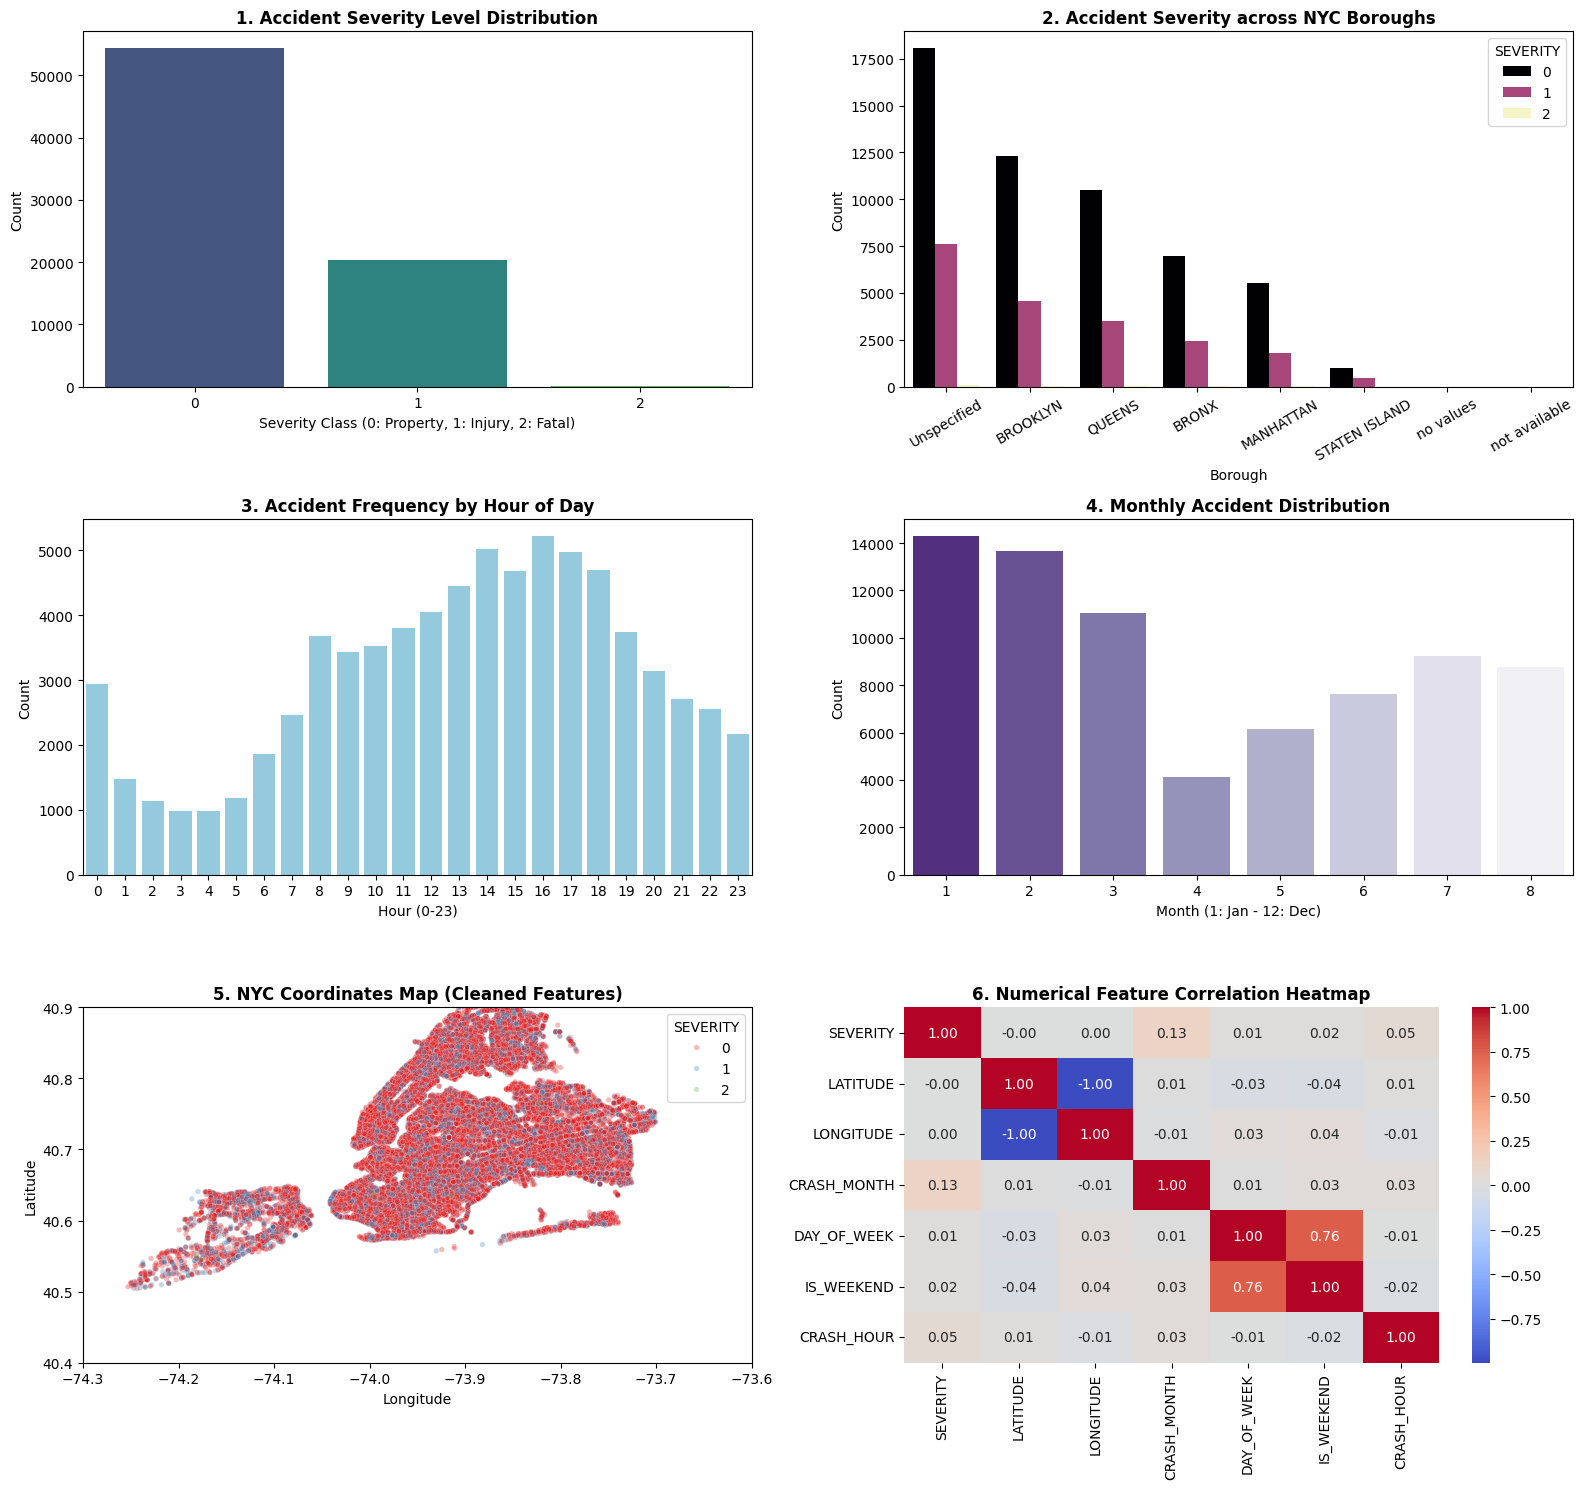

In [25]:
# ==========================================
# CELL 6: POST-CLEANING 6-SUBPLOT EDA DASHBOARD
# ==========================================
plt.figure(figsize=(16, 15))

# Plot 1: Target Severity Distribution
plt.subplot(3, 2, 1)
sns.countplot(x='SEVERITY', data=df, palette='viridis')
plt.title('1. Accident Severity Level Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Severity Class (0: Property, 1: Injury, 2: Fatal)')
plt.ylabel('Count')

# Plot 2: Accidents by Borough grouped by Severity
plt.subplot(3, 2, 2)
sns.countplot(x='BOROUGH', hue='SEVERITY', data=df, palette='magma', order=df['BOROUGH'].value_counts().index)
plt.title('2. Accident Severity across NYC Boroughs', fontsize=12, fontweight='bold')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.xticks(rotation=30)

# Plot 3: Hourly Accident Trends
plt.subplot(3, 2, 3)
sns.countplot(x='CRASH_HOUR', data=df, color='skyblue')
plt.title('3. Accident Frequency by Hour of Day', fontsize=12, fontweight='bold')
plt.xlabel('Hour (0-23)')
plt.ylabel('Count')

# Plot 4: Monthly Trend of Crashes
plt.subplot(3, 2, 4)
sns.countplot(x='CRASH_MONTH', data=df, palette='Purples_r')
plt.title('4. Monthly Accident Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Month (1: Jan - 12: Dec)')
plt.ylabel('Count')

# Plot 5: Spatial Geographic Map
plt.subplot(3, 2, 5)
sns.scatterplot(x='LONGITUDE', y='LATITUDE', hue='SEVERITY', data=df, alpha=0.3, palette='Set1', s=15)
plt.title('5. NYC Coordinates Map (Cleaned Features)', fontsize=12, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-74.3, -73.6)
plt.ylim(40.4, 40.9)

# Plot 6: Feature Correlation Heatmap
plt.subplot(3, 2, 6)
numeric_features = ['SEVERITY', 'LATITUDE', 'LONGITUDE', 'CRASH_MONTH', 'DAY_OF_WEEK', 'IS_WEEKEND', 'CRASH_HOUR']
sns.heatmap(df[numeric_features].corr(), cmap='coolwarm', annot=True, fmt='.2f', cbar=True)
plt.title('6. Numerical Feature Correlation Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('nyc_accident_eda_adaboost.png', dpi=300)
plt.show()

In [26]:
# ==========================================
# CELL 7: FEATURE SELECTION & ENCODING
# ==========================================
selected_features = [
    'BOROUGH', 'LATITUDE', 'LONGITUDE', 
    'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1',
    'CRASH_MONTH', 'DAY_OF_WEEK', 'IS_WEEKEND', 'CRASH_HOUR'
]

X = df[selected_features].copy()
y = df['SEVERITY']

# Encoding categorical text columns
for col in ['BOROUGH', 'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X.head()

,BOROUGH,LATITUDE,LONGITUDE,CONTRIBUTING FACTOR VEHICLE 1,VEHICLE TYPE CODE 1,CRASH_MONTH,DAY_OF_WEEK,IS_WEEKEND,CRASH_HOUR
0,0,40.89210,-73.833760,31,179,8,5,1,15
1,1,40.69050,-73.919914,38,179,8,5,1,21
2,7,40.81650,-73.946556,4,182,8,5,1,18
3,0,40.82472,-73.892960,49,182,8,5,1,0
4,1,40.64989,-73.933890,14,179,8,5,1,17


In [27]:
# ==========================================
# CELL 8: TRAIN-TEST SPLIT, SCALING & SMOTE
# ==========================================
# 1. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Standard Scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# 3. SMOTE Resampling for Class Imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"✅ Training set shape after SMOTE: {X_train_res.shape}")

✅ Training set shape after SMOTE: (130488, 9)


In [28]:
# ==========================================
# CELL 9: TRAIN ADABOOST CLASSIFIER
# ==========================================
print("Training AdaBoost Classifier...")

# Define base decision tree estimator with depth=5 for higher capacity
tree_base = DecisionTreeClassifier(max_depth=5, random_state=42)

# Robust initialization handling both scikit-learn >= 1.2 ('estimator') and < 1.2 ('base_estimator')
try:
    adaboost_model = AdaBoostClassifier(
        estimator=tree_base,
        n_estimators=100,
        learning_rate=0.08,
        random_state=42
    )
except TypeError:
    adaboost_model = AdaBoostClassifier(
        base_estimator=tree_base,
        n_estimators=100,
        learning_rate=0.08,
        random_state=42
    )

# Train the AdaBoost model
adaboost_model.fit(X_train_res, y_train_res)

print("✅ AdaBoost Model ('adaboost_model') Trained Successfully!")

Training AdaBoost Classifier...
✅ AdaBoost Model ('adaboost_model') Trained Successfully!


In [29]:
# ==========================================
# CELL 10: EVALUATION & PERFORMANCE METRICS
# ==========================================
# Make predictions on scaled test data
y_pred_ada = adaboost_model.predict(X_test_scaled)

# Calculate Evaluation Metrics
acc = accuracy_score(y_test, y_pred_ada) * 100
prec = precision_score(y_test, y_pred_ada, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred_ada, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_ada, average='weighted', zero_division=0)
mae = mean_absolute_error(y_test, y_pred_ada)

# Summary DataFrame
results_df = pd.DataFrame({
    'Algorithm': ['AdaBoost'],
    'Accuracy (%)': [f"{acc:.2f}"],
    'Precision': [f"{prec:.4f}"],
    'Recall': [f"{rec:.4f}"],
    'F1-Score': [f"{f1:.4f}"],
    'MAE': [f"{mae:.4f}"]
})

print("=== AdaBoost Performance Summary ===")
print(results_df.to_string(index=False))

print("\n=== Detailed Classification Report ===")
print(classification_report(y_test, y_pred_ada, target_names=['Property Damage', 'Injury', 'Fatal']))

=== AdaBoost Performance Summary ===
Algorithm Accuracy (%) Precision Recall F1-Score    MAE
 AdaBoost        64.33    0.6694 0.6433   0.6551 0.3673

=== Detailed Classification Report ===
                 precision    recall  f1-score   support

Property Damage       0.78      0.72      0.75     10875
         Injury       0.38      0.43      0.40      4075
          Fatal       0.01      0.11      0.02        27

       accuracy                           0.64     14977
      macro avg       0.39      0.42      0.39     14977
   weighted avg       0.67      0.64      0.66     14977



Computing SHAP values for AdaBoost...


C:\Users\PL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\PL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\PL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\PL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-pac

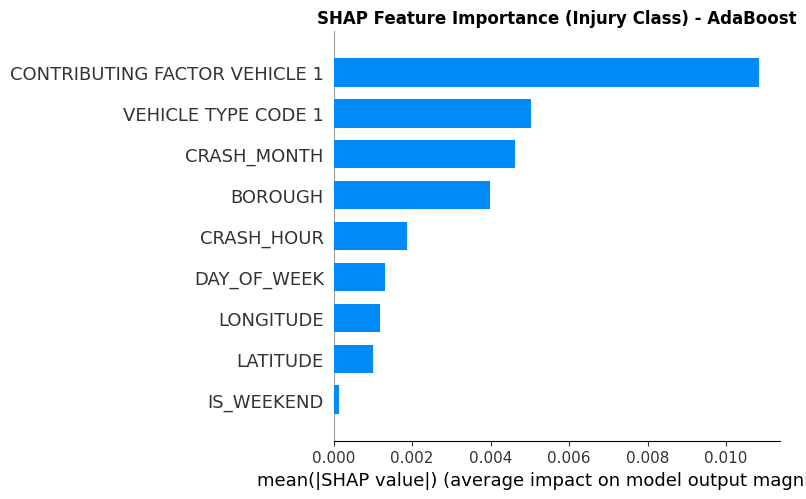

C:\Users\PL\AppData\Local\Temp\ipykernel_15636\2065943987.py:39: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


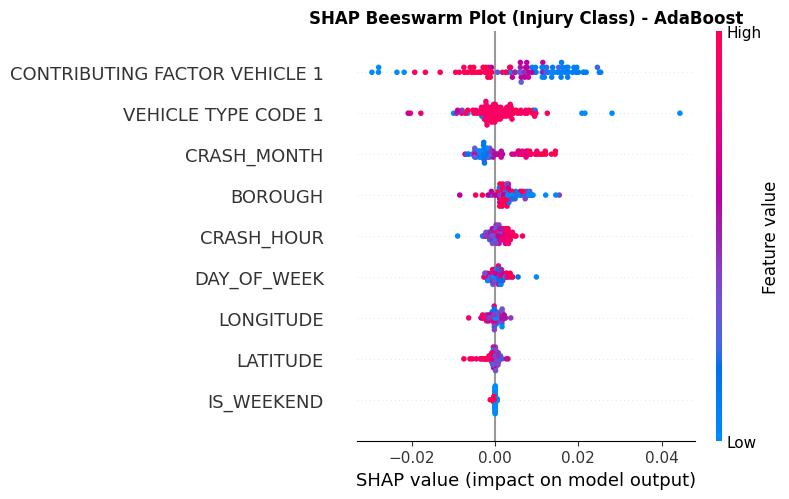

In [31]:
# ==========================================
# CELL 11: SHAP EXPLAINER FOR ADABOOST (FIXED)
# ==========================================
print("Computing SHAP values for AdaBoost...")

# Wrapper function returning class probabilities for SHAP
def predict_proba_adaboost(X_array):
    return adaboost_model.predict_proba(X_array)

# Background sample for Kernel/Generic Explainer
background_data = X_train_res.sample(50, random_state=42).values
explainer = shap.Explainer(predict_proba_adaboost, background_data)

# Test evaluation subset
X_shap = X_test_scaled.iloc[:100]
shap_explanation = explainer(X_shap.values)

# Extract SHAP values for Class 1 (Injury)
if len(shap_explanation.shape) == 3:
    shap_vals_class1 = shap_explanation.values[:, :, 1]
else:
    shap_vals_class1 = shap_explanation.values

# Plot 1: Feature Importance Bar Chart
plt.figure(figsize=(10, 5))
plt.title('SHAP Feature Importance (Injury Class) - AdaBoost', fontsize=12, fontweight='bold')
shap.summary_plot(
    shap_vals_class1, 
    X_shap, 
    plot_type="bar", 
    show=False
)
plt.tight_layout()
plt.show()

# Plot 2: SHAP Beeswarm Plot
plt.figure(figsize=(10, 5))
plt.title('SHAP Beeswarm Plot (Injury Class) - AdaBoost', fontsize=12, fontweight='bold')
shap.summary_plot(
    shap_vals_class1, 
    X_shap, 
    show=False
)
plt.tight_layout()
plt.show()